#Uber_Fare_Price_Analysis_and_Prediction


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
uber_df=pd.read_csv('/content/drive/MyDrive/uber.csv')

In [6]:
uber_df.shape

(200000, 9)

In [7]:
uber_df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [8]:
uber_df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [9]:
uber_df.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1
199999,11951496,2010-05-15 04:08:00.00000076,14.1,2010-05-15 04:08:00 UTC,-73.984395,40.720077,-73.985508,40.768793,1


#findig null value


In [10]:
uber_df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


#one null value exist,there is no information about drop off so,it has been deleted among 200000 rows.

In [11]:
uber_df[uber_df.isnull().any(axis=1)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [12]:
uber_df.dropna(inplace=True)
uber_df.isnull().sum()


,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [13]:
uber_df.describe()


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,1.601386e+07,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382534e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774524e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155535e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [14]:
uber_df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [15]:
#Removing extra add unnamed column
uber_df.drop(columns=['Unnamed: 0'],axis=0,inplace=True)

In [16]:
uber_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [17]:
uber_df['key']

,key
0,2015-05-07 19:52:06.0000003
1,2009-07-17 20:04:56.0000002
2,2009-08-24 21:45:00.00000061
3,2009-06-26 08:22:21.0000001
4,2014-08-28 17:47:00.000000188
...,...
199995,2012-10-28 10:49:00.00000053
199996,2014-03-14 01:09:00.0000008
199997,2009-06-29 00:42:00.00000078
199998,2015-05-20 14:56:25.0000004


In [18]:
uber_df['key'].dtype

dtype('O')

#convert key from dtype-'object' to dtype- 'datetime64'

In [19]:
uber_df['key']=pd.to_datetime(uber_df['key'],errors='coerce')


In [20]:
uber_df['key'].dtype

dtype('<M8[ns]')

In [21]:
uber_df

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...
199995,2012-10-28 10:49:00.000000530,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,2014-03-14 01:09:00.000000800,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,2009-06-29 00:42:00.000000780,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,2015-05-20 14:56:25.000000400,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


##Fearure Engineering where year month day,hour,minute,seconds are separated

In [22]:

uber_df['year']=uber_df['key'].dt.year
uber_df['month']=uber_df['key'].dt.month
uber_df['day']=uber_df['key'].dt.day
uber_df['hour']=uber_df['key'].dt.hour
uber_df['minute']=uber_df['key'].dt.minute
uber_df['second']=uber_df['key'].dt.second


uber_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,minute,second
0,2015-05-07 19:52:06.000000300,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,52,6
1,2009-07-17 20:04:56.000000200,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,56
2,2009-08-24 21:45:00.000000610,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,45,0
3,2009-06-26 08:22:21.000000100,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,22,21
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,47,0


In [23]:
uber_df = uber_df.sort_values(by="key")
uber_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,minute,second
100844,2009-01-01 01:15:22.000000600,8.5,2009-01-01 01:15:22 UTC,-73.981918,40.779456,-73.957685,40.771043,2,2009,1,1,1,15,22
43961,2009-01-01 01:59:17.000000100,13.0,2009-01-01 01:59:17 UTC,-73.983759,40.721389,-73.994833,40.687179,2,2009,1,1,1,59,17
7628,2009-01-01 02:05:03.000000300,10.6,2009-01-01 02:05:03 UTC,-73.956635,40.771254,-73.991528,40.749778,2,2009,1,1,2,5,3
118760,2009-01-01 02:09:13.000000300,12.2,2009-01-01 02:09:13 UTC,-73.984605,40.728020,-73.955746,40.776830,1,2009,1,1,2,9,13
89763,2009-01-01 02:13:41.000000100,11.0,2009-01-01 02:13:41 UTC,-73.980127,40.737425,-74.009544,40.726025,4,2009,1,1,2,13,41


##Finding the part of the day according to date and time is it morning or afternoon or night

In [24]:

def get_part_of_day(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 20:
        return "evening"
    else:
        return "night"

uber_df["part_of_day"] = uber_df["hour"].apply(get_part_of_day)

In [25]:
uber_df.tail()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,minute,second,part_of_day
2173,2015-06-30 22:57:53.000000500,18.5,2015-06-30 22:57:53 UTC,-73.971703,40.782207,-73.943680,40.827991,2,2015,6,30,22,57,53,night
80850,2015-06-30 23:16:42.000000200,25.5,2015-06-30 23:16:42 UTC,-74.001099,40.730961,-73.957123,40.806908,2,2015,6,30,23,16,42,night
56905,2015-06-30 23:31:06.000000200,20.0,2015-06-30 23:31:06 UTC,-73.999962,40.733135,-73.962448,40.773041,4,2015,6,30,23,31,6,night
32718,2015-06-30 23:33:33.000000200,8.5,2015-06-30 23:33:33 UTC,-73.980988,40.762020,-73.960083,40.770531,1,2015,6,30,23,33,33,night
162593,2015-06-30 23:40:39.000000100,27.0,2015-06-30 23:40:39 UTC,-73.984795,40.751411,-73.927765,40.706287,1,2015,6,30,23,40,39,night


##doing feature engineering by creating new feature as is the day weekday or weekend for model  

In [26]:
uber_df["pickup_datetime"] = pd.to_datetime(uber_df["pickup_datetime"])

uber_df["is_weekend"] = (uber_df["pickup_datetime"].dt.dayofweek >= 5).astype(int)

In [27]:
uber_df["is_weekend"].value_counts()

,count
is_weekend,
0,143307
1,56692


In [28]:
uber_df["part_of_day"].value_counts()

,count
part_of_day,
night,67823
morning,50117
afternoon,47624
evening,34435


In [29]:
uber_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,minute,second,part_of_day,is_weekend
100844,2009-01-01 01:15:22.000000600,8.5,2009-01-01 01:15:22+00:00,-73.981918,40.779456,-73.957685,40.771043,2,2009,1,1,1,15,22,night,0
43961,2009-01-01 01:59:17.000000100,13.0,2009-01-01 01:59:17+00:00,-73.983759,40.721389,-73.994833,40.687179,2,2009,1,1,1,59,17,night,0
7628,2009-01-01 02:05:03.000000300,10.6,2009-01-01 02:05:03+00:00,-73.956635,40.771254,-73.991528,40.749778,2,2009,1,1,2,5,3,night,0
118760,2009-01-01 02:09:13.000000300,12.2,2009-01-01 02:09:13+00:00,-73.984605,40.728020,-73.955746,40.776830,1,2009,1,1,2,9,13,night,0
89763,2009-01-01 02:13:41.000000100,11.0,2009-01-01 02:13:41+00:00,-73.980127,40.737425,-74.009544,40.726025,4,2009,1,1,2,13,41,night,0


##creating new feature 'Distance' by using Haversine Formulla to calculate distance on a sphere


In [30]:
import math
def cal_distance(pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude):
  R=6341 #earth radious
  pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude=map(math.radians, [pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude])
  d_lon=dropoff_longitude-pickup_longitude
  d_lat=dropoff_latitude-pickup_latitude
  #formulla
  a = math.sin(d_lat/2)**2 + math.cos(pickup_latitude) * math.cos(dropoff_latitude) * math.sin(d_lon/2)**2
  c = 2 * math.asin(math.sqrt(a))
  return R * c

##aplying this function to calculate every distance


In [31]:
uber_df['distance in km']=uber_df.apply(
    lambda row: cal_distance(
        row["pickup_latitude"],
        row["pickup_longitude"],
        row["dropoff_latitude"],
        row["dropoff_longitude"]
    ),
    axis=1
)

In [32]:
uber_df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,minute,second,part_of_day,is_weekend,distance in km
100844,2009-01-01 01:15:22.000000600,8.5,2009-01-01 01:15:22+00:00,-73.981918,40.779456,-73.957685,40.771043,2,2009,1,1,1,15,22,night,0,2.694195
43961,2009-01-01 01:59:17.000000100,13.0,2009-01-01 01:59:17+00:00,-73.983759,40.721389,-73.994833,40.687179,2,2009,1,1,1,59,17,night,0,1.610128
7628,2009-01-01 02:05:03.000000300,10.6,2009-01-01 02:05:03+00:00,-73.956635,40.771254,-73.991528,40.749778,2,2009,1,1,2,5,3,night,0,3.917005
118760,2009-01-01 02:09:13.000000300,12.2,2009-01-01 02:09:13+00:00,-73.984605,40.728020,-73.955746,40.776830,1,2009,1,1,2,9,13,night,0,3.525026
89763,2009-01-01 02:13:41.000000100,11.0,2009-01-01 02:13:41+00:00,-73.980127,40.737425,-74.009544,40.726025,4,2009,1,1,2,13,41,night,0,3.274151


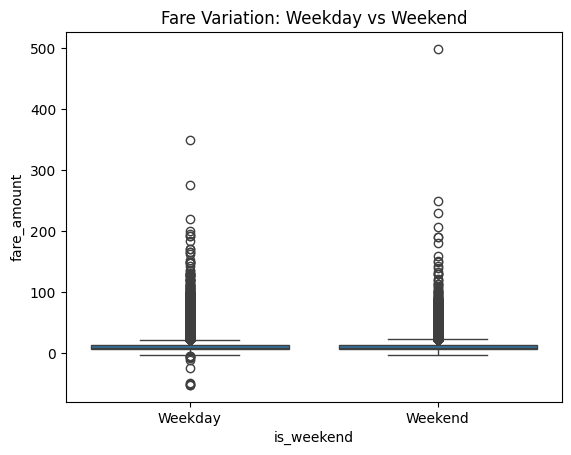

In [33]:


sns.boxplot(x="is_weekend", y="fare_amount", data=uber_df)
plt.xticks([0,1], ["Weekday", "Weekend"])
plt.title("Fare Variation: Weekday vs Weekend")
plt.show()

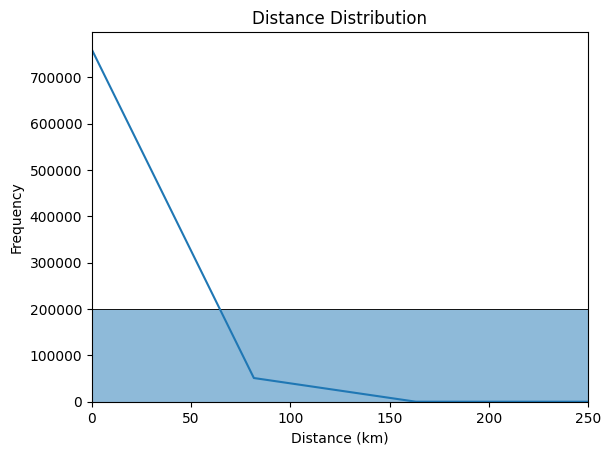

In [34]:
sns.histplot(uber_df["distance in km"], bins=50, kde=True)
plt.title("Distance Distribution")
plt.xlabel("Distance (km)")
plt.xlim(0,250)
plt.ylabel("Frequency")
plt.show()

In [35]:
uber_df['distance in km'].isnull().value_counts()

,count
distance in km,
False,199999


In [36]:
uber_df[uber_df["distance in km"] == 0].shape

(5632, 17)

In [37]:
uber_df[uber_df["distance in km"] > 0].shape

(194367, 17)

In [38]:
uber_df[uber_df["fare_amount"] == 0].shape

(5, 17)

In [39]:
uber_df=uber_df[uber_df['distance in km']>0]

In [40]:
uber_df=uber_df[uber_df['fare_amount']>0]

##many rows have same pickup and drop off location so it shows 0 thats why the data frame has removed those rows

In [41]:
uber_df.shape

(194347, 17)

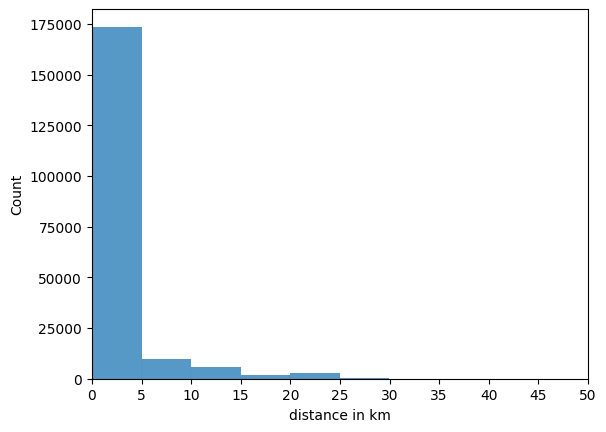

In [42]:
import matplotlib.pyplot as plt

plt.figure()   # creates new plot

sns.histplot(uber_df["distance in km"], binwidth=5)
plt.xlim(0, 50)
plt.xticks(np.arange(0,51,5))

plt.show()

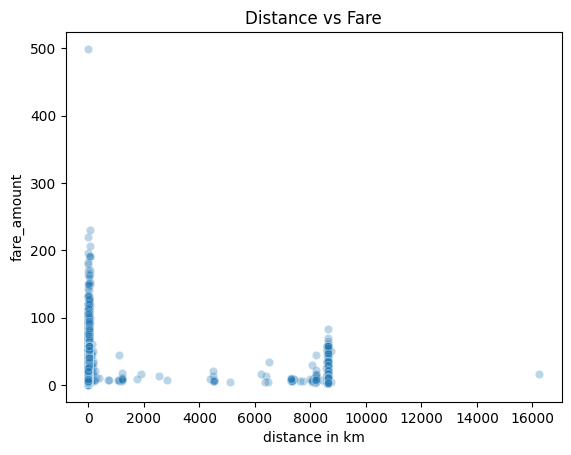

In [43]:
sns.scatterplot(x="distance in km", y="fare_amount", data=uber_df, alpha=0.3)
plt.title("Distance vs Fare")

plt.show()

In [44]:
uber_df["distance in km"].describe()

,distance in km
count,194347.000000
mean,20.905353
std,392.203719
min,0.000030
25%,0.874247
50%,1.567180
75%,2.852966
max,16244.475614


##removing outliers


In [45]:
uber_df = uber_df[(uber_df["distance in km"] > 0) & (uber_df["distance in km"] < 50)]

In [46]:
uber_df["distance in km"].describe()

,distance in km
count,193873.000000
mean,2.714527
std,3.775680
min,0.000030
25%,0.872560
50%,1.563084
75%,2.838639
max,49.216735


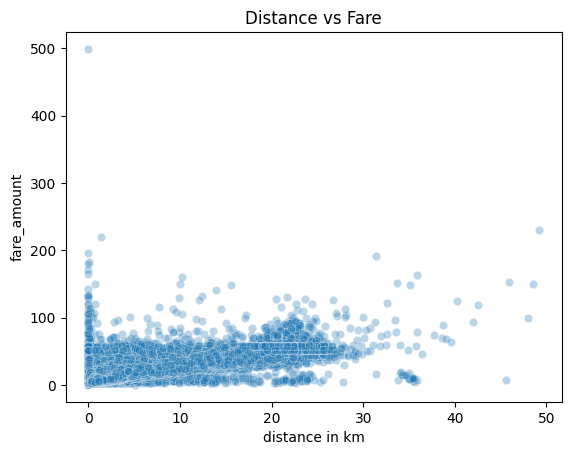

In [47]:
sns.scatterplot(x="distance in km", y="fare_amount", data=uber_df, alpha=0.3)
plt.title("Distance vs Fare")

plt.show()

In [48]:
uber_df['fare_amount'].describe()

,fare_amount
count,193873.000000
mean,11.342300
std,9.690559
min,0.010000
25%,6.000000
50%,8.500000
75%,12.500000
max,499.000000


In [49]:
uber_df = uber_df[(uber_df["fare_amount"] > 0) & (uber_df["fare_amount"] < 200)]

In [50]:
uber_df["fare_amount"].describe()

,fare_amount
count,193870.000000
mean,11.337580
std,9.602631
min,0.010000
25%,6.000000
50%,8.500000
75%,12.500000
max,196.000000


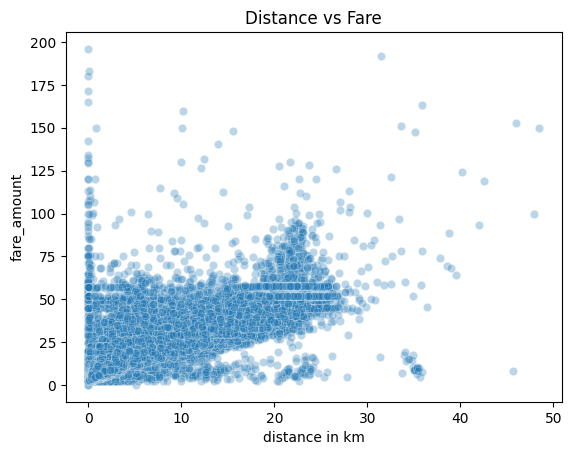

In [51]:
sns.scatterplot(x="distance in km", y="fare_amount", data=uber_df, alpha=0.3)
plt.title("Distance vs Fare")

plt.show()

In [52]:
uber_df=uber_df[uber_df["distance in km"] > 0.1]

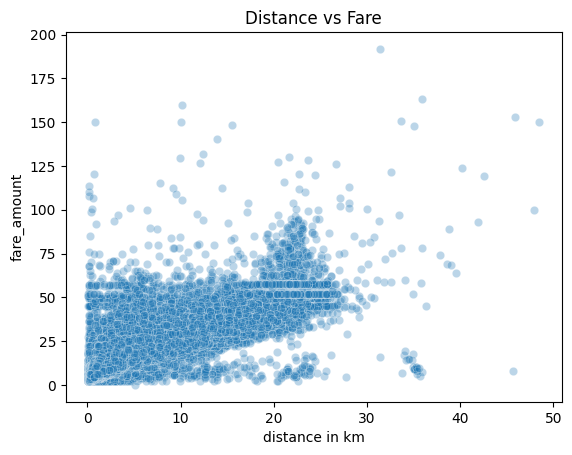

In [53]:
sns.scatterplot(x="distance in km", y="fare_amount", data=uber_df, alpha=0.3)
plt.title("Distance vs Fare")

plt.show()

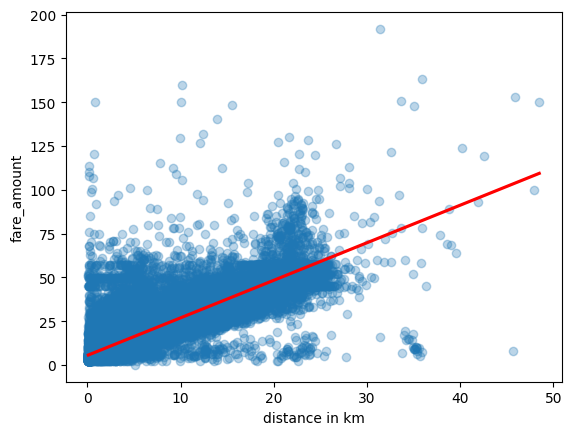

In [54]:
sns.regplot(
    x="distance in km",
    y="fare_amount",
    data=uber_df,
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)
plt.show()

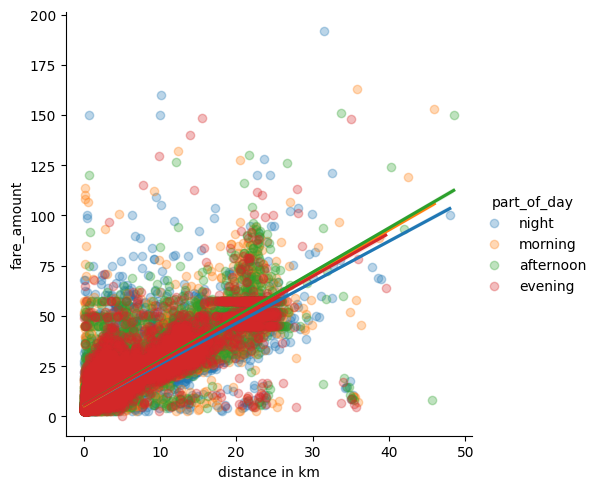

In [55]:
sns.lmplot(
    x="distance in km",
    y="fare_amount",
    hue="part_of_day",
    data=uber_df,
    scatter_kws={"alpha":0.3}
)

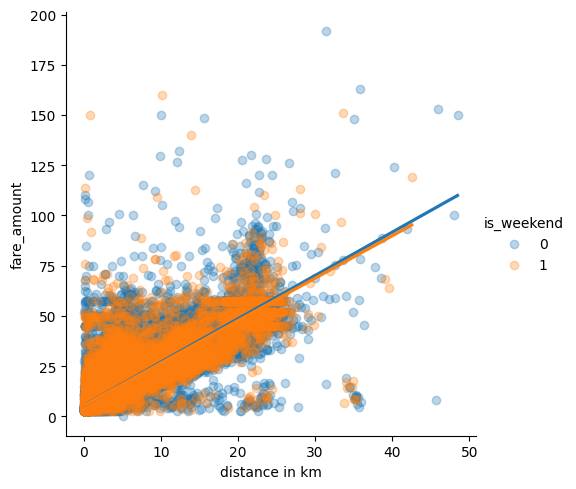

In [56]:
sns.lmplot(
    x="distance in km",
    y="fare_amount",
    hue="is_weekend",
    data=uber_df,
    scatter_kws={"alpha":0.3}
)

<Axes: xlabel='distance in km', ylabel='fare_amount'>

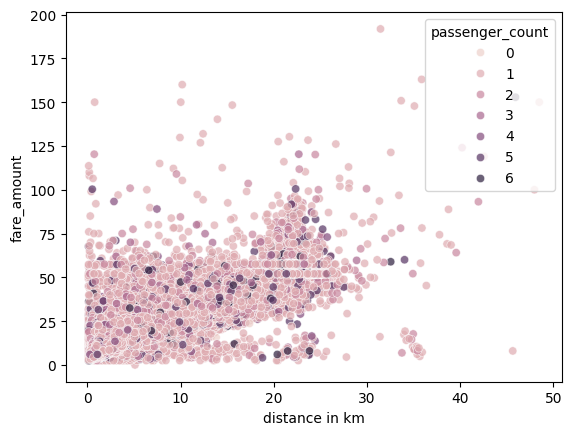

In [62]:
sns.scatterplot(
    x="distance in km",
    y="fare_amount",
    hue="passenger_count",
    data=uber_df,
    alpha=0.7
)

In [72]:
uber_df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'year', 'month', 'day', 'hour', 'minute', 'second',
       'is_weekend', 'distance in km', 'part_of_day_evening',
       'part_of_day_morning', 'part_of_day_night'],
      dtype='object')

##creating a Linear regression model on sklearn


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [75]:
x=uber_df[['distance in km','is_weekend','passenger_count',"part_of_day_morning",
    "part_of_day_evening",
    "part_of_day_night"]]
y=uber_df['fare_amount']

In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=21)

In [77]:
model= LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [78]:
y_pred = model.predict(x_test)

##checking the R2 score,Mean absolute error,and RMAE score for the model

In [79]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.737115428188738
MAE: 2.9550181831402655
RMSE: 4.848330748077557


##giving new data for prediction


In [97]:
new_data = pd.DataFrame({
    "distance in km": [10],
    "is_weekend": [1],
    "passenger_count":[2],
    "part_of_day_morning": [0],
    "part_of_day_evening": [1],
    "part_of_day_night": [0]
})


In [98]:

prediction = model.predict(new_data)
print(prediction)

[26.9243377]


In [99]:
new_data2 = pd.DataFrame({
    "distance in km": [15],
    "is_weekend": [0],
    "passenger_count":[1],
    "part_of_day_morning": [0],
    "part_of_day_evening": [0],
    "part_of_day_night": [1]
})
prediction = model.predict(new_data2)
print(prediction)

[37.43021111]


In [100]:
new_data3 = pd.DataFrame({
    "distance in km": [6],
    "is_weekend": [0],
    "passenger_count":[3],
    "part_of_day_morning": [0],
    "part_of_day_evening": [1],
    "part_of_day_night": [0]
})
prediction = model.predict(new_data3)
print(prediction)

[18.58149714]
